# DATA CLEANING

In [18]:
import pandas as pd
import numpy as np


df=pd.read_csv("D:/cyber securitiy analysis/dataset/raw_cybersecurity_dataset.csv",encoding="latin1")

df.columns=df.columns.str.strip()
df.columns=df.columns.str.lower().str.replace(" ","_") 

print("\nINF0:-")
print(df.info(),"\n\n")

print("\nDATASET SHAPE:-",df.shape,"\n\n")

print("duplicates rows:-",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("duplicates rows:-",df.duplicated().sum(),"   DUPLICATES REMOVED SUCCESSFULLY\n\n")

print("MISSING VALUES BY COLUMNS:-")
print(df.isnull().sum(),"\n\n")
df.fillna(0, inplace=True)
print("HANDLED MISSING VALUES SUCCESSFULLY\n\n")  
print(df.isnull().sum(),"\n\n")

df.replace([np.inf, -np.inf], np.nan, inplace=True)    

df['timestamp'] = pd.to_datetime(df['timestamp'])
print("CHANGED TIMESTAMP DATATYPE\n\n")

df.to_csv("cleaned_cybersecurity_dataset.csv", index=False) 
print("DATASET SAVED SUCCESSFULLY\n\n")




INF0:-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170366 entries, 0 to 170365
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   source_ip                    170366 non-null  object 
 1   source_port                  170366 non-null  int64  
 2   destination_ip               170366 non-null  object 
 3   destination_port             170366 non-null  int64  
 4   protocol                     170366 non-null  int64  
 5   timestamp                    170366 non-null  object 
 6   flow_duration                170366 non-null  int64  
 7   total_fwd_packets            170366 non-null  int64  
 8   total_backward_packets       170366 non-null  int64  
 9   total_length_of_fwd_packets  170366 non-null  int64  
 10  total_length_of_bwd_packets  170366 non-null  float64
 11  flow_bytes/s                 170346 non-null  float64
 12  flow_packets/s               170366 non-null  floa

# FEATURE ENGINNERING

In [21]:
import pandas as pd
df=pd.read_csv("D:/cyber securitiy analysis/dataset/cleaned_cybersecurity_dataset.csv")

#1.ATTACK FLAG
df["attack_flag"]=df["label"].apply(lambda x:0 if x=="BENIGN" else 1)

#2.RISK SCORE
df["risk_score"]=df["syn_flag_count"]+df["ack_flag_count"]+df["rst_flag_count"]

#3.HIGH TRAFFIC DETECTIION
threshold=df["flow_bytes/s"].quantile(0.95)
df["high_traffic"]=(df["flow_bytes/s"]>threshold).astype(int)

df.to_csv("cleaned_cybersecurity_dataset.csv", index=False) 

print("SAVED SUCCESSFULLY")

SAVED SUCCESSFULLY


# EXPLORATORY DATA ANALYSIS

In [19]:
import pandas as pd
import numpy as np

df=pd.read_csv("D:/cyber securitiy analysis/dataset/cleaned_cybersecurity_dataset.csv",encoding="latin1")

print("\nDISTRIBUTION OF TRAFFIC BY LABEL")
print(df['label'].value_counts(),"\n\n")


DISTRIBUTION OF TRAFFIC BY LABEL
label
BENIGN                         168183
Web Attack Â Brute Force        1507
Web Attack Â XSS                 652
Web Attack Â Sql Injection        21
Name: count, dtype: int64 




C:\Users\SAICHARAN\AppData\Local\Temp\ipykernel_17296\2985738342.py:15: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SAICHARAN\AppData\Local\Temp\ipykernel_17296\2985738342.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\SAICHARAN\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


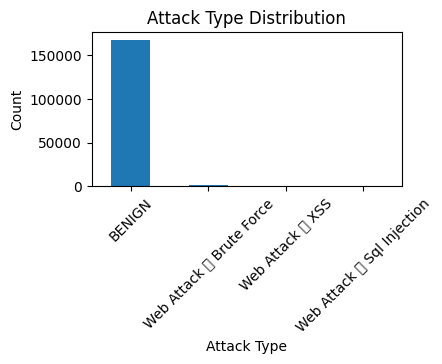

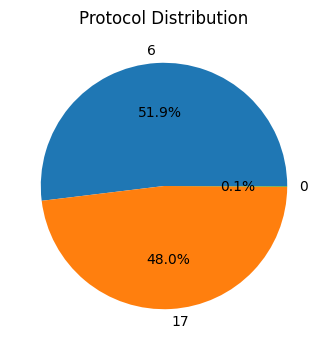

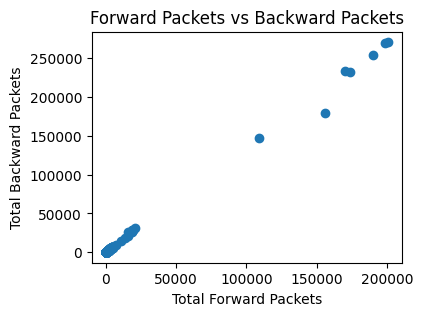

In [24]:
#MATPLOT MODULE

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("cleaned_cybersecurity_dataset.csv")


plt.figure(figsize=(4,2))
df['label'].value_counts().plot(kind='bar')
plt.title('Attack Type Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(4,4))
df['protocol'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Protocol Distribution')
plt.ylabel('')
plt.show()


plt.figure(figsize=(4,3))
plt.scatter(df['total_fwd_packets'],df['total_backward_packets'])
plt.title('Forward Packets vs Backward Packets')
plt.xlabel('Total Forward Packets')
plt.ylabel('Total Backward Packets')
plt.show()


C:\Users\SAICHARAN\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


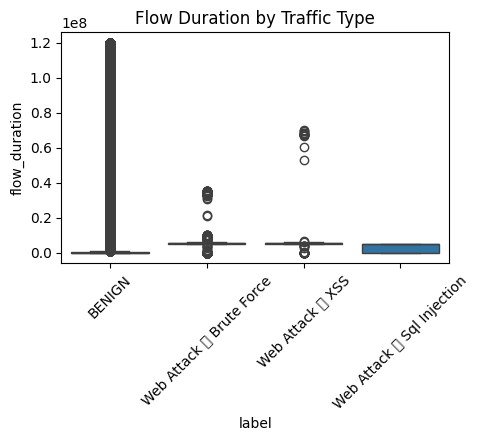

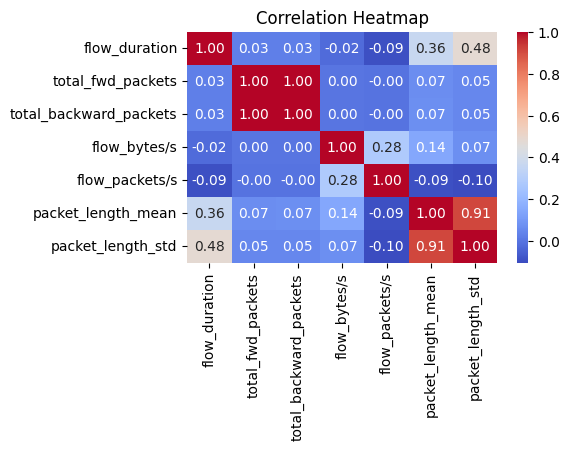

C:\Users\SAICHARAN\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


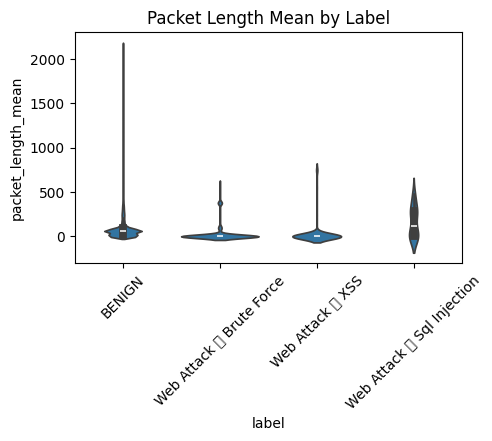

In [30]:
#SEABORN MODULE

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("cleaned_cybersecurity_dataset.csv")


plt.figure(figsize=(5,3))
sns.boxplot(x='label',y='flow_duration',data=df)
plt.title("Flow Duration by Traffic Type")
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(5,3))
features = ['flow_duration','total_fwd_packets','total_backward_packets','flow_bytes/s','flow_packets/s','packet_length_mean','packet_length_std']
corr = df[features].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


plt.figure(figsize=(5,3))
sns.violinplot(x='label',y='packet_length_mean',data=df)
plt.title("Packet Length Mean by Label")
plt.xticks(rotation=45)
plt.show()